In [2]:
import tensorflow as tf
from keras import layers, regularizers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset shape: {X.shape}")
print(f"Features: {len(feature_names)}")
print(f"Classes: {target_names}")
print(f"Class distribution: {np.bincount(y)}")

# normalizar features
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = tf.constant(X_train, dtype=tf.float32)
X_test = tf.constant(X_test, dtype=tf.float32)
y_train = tf.constant(y_train, dtype=tf.float32)
y_test = tf.constant(y_test, dtype=tf.float32)

y_train = tf.expand_dims(y_train, -1)
y_test = tf.expand_dims(y_test, -1)

print(f"\nTrain set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")


Dataset shape: (569, 30)
Features: 30
Classes: ['malignant' 'benign']
Class distribution: [212 357]

Train set: (455, 30), (455, 1)
Test set: (114, 30), (114, 1)


In [ ]:
def create_model(model_type, n_features, hidden_units=64, dropout_rate=0.5, l1_reg=0.001, l2_reg=0.001 ):
	model = tf.keras.Sequential()
	model.add(layers.Input(shape=(n_features,)))

	if model_type == 'baseline':
		model.add(layers.Dense(hidden_units, activation='relu'))
		model.add(layers.Dense(hidden_units, activation='relu'))
		model.add(layers.Dense(hidden_units, activation='relu'))

	elif model_type == 'l1':
		model.add(layers.Dense(hidden_units, activation='relu',
						kernel_regularizer=regularizers.l1(l1_reg)))
		model.add(layers.Dense(hidden_units, activation='relu',
						kernel_regularizer=regularizers.l1(l1_reg)))
		model.add(layers.Dense(hidden_units, activation='relu',
						kernel_regularizer=regularizers.l1(l1_reg)))

	elif model_type == 'l2':
		model.add(layers.Dense(hidden_units, activation='relu',
						kernel_regularizer=regularizers.l2(l2_reg)))
		model.add(layers.Dense(hidden_units, activation='relu',
						kernel_regularizer=regularizers.l2(l2_reg)))
		model.add(layers.Dense(hidden_units, activation='relu',
						kernel_regularizer=regularizers.l2(l2_reg)))

	elif model_type == 'dropout':
		model.add(layers.Dense(hidden_units, activation='relu',))
		model.add(layers.Dropout(dropout_rate))
		model.add(layers.Dense(hidden_units, activation='relu'))
		model.add(layers.Dropout(dropout_rate))
		model.add(layers.Dense(hidden_units, activation='relu'))
		model.add(layers.Dropout(dropout_rate))

	elif model_type == 'combined':
		model.add(layers.Dense(hidden_units, kernel_regularizer=regularizers.l2(l2_reg),
		activation='relu'))
		model.add(layers.Dropout(dropout_rate))
		model.add(layers.Dense(hidden_units, kernel_regularizer=regularizers.l2(l2_reg),
		activation='relu'))
		model.add(layers.Dropout(dropout_rate))
		model.add(layers.Dense(hidden_units, kernel_regularizer=regularizers.l2(l2_reg),
		activation='relu'))
		model.add(layers.Dropout(dropout_rate))

	model.add(layers.Dense(1, activation='sigmoid'))

	return model

In [5]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=100,batch_size=32, verbose=0):
		optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
		model.compile(
			optimizer=optimizer,
			loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),  # Changed to False since we use sigmoid
			metrics=['accuracy']
		)

		callbacks = [
			tf.keras.callbacks.EarlyStopping(
				monitor='val_loss',
				patience=15,
				restore_best_weights=True
			),
			tf.keras.callbacks.ReduceLROnPlateau(
				monitor='val_loss',
				factor=0.5,
				patience=5,
				min_lr=1e-7
			)
		]

		history = model.fit(
			X_train, y_train,
			validation_data=(X_test, y_test),
			epochs=epochs,
			batch_size=batch_size,
			callbacks=callbacks,
			verbose=verbose
		)

		return history

In [ ]:
model_types = ['baseline', 'l1', 'l2', 'dropout', 'combined']
results = {}
print("=" * 60)

for model_type in model_types:
	print(f"Treinando modelo {model_type}...")

	model = create_model(
		model_type,
		n_features=X_train.shape[1],
		hidden_units=64,
		dropout_rate=0.5,
		l1_reg=0.001,
		l2_reg=0.001
	)

	history = train_model(
		model, X_train, y_train, X_test, y_test,
		epochs=100, verbose=0
	)

	train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
	test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

	results[model_type] = {
		'train_accuracy': train_acc,
		'test_accuracy': test_acc,
		'train_loss': train_loss,
		'test_loss': test_loss,
		'history': history,
		'model': model
	}

	print(f"  Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")
	print(f"  Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
	print(f"  Overfitting: {train_acc - test_acc:.4f}")

print("=" * 60)







Treinando modelo baseline...
  Train Acc: 0.9934, Test Acc: 0.9561
  Train Loss: 0.0421, Test Loss: 0.0826
  Overfitting: 0.0373
Treinando modelo l1...
  Train Acc: 1.0000, Test Acc: 0.9561
  Train Loss: 0.0633, Test Loss: 0.1600
  Overfitting: 0.0439
Treinando modelo l2...
  Train Acc: 1.0000, Test Acc: 0.9737
  Train Loss: 0.0390, Test Loss: 0.1258
  Overfitting: 0.0263
Treinando modelo dropout...
  Train Acc: 0.9846, Test Acc: 0.9649
  Train Loss: 0.0591, Test Loss: 0.0842
  Overfitting: 0.0197
Treinando modelo combined...
  Train Acc: 0.9912, Test Acc: 0.9561
  Train Loss: 0.1570, Test Loss: 0.2182
  Overfitting: 0.0351


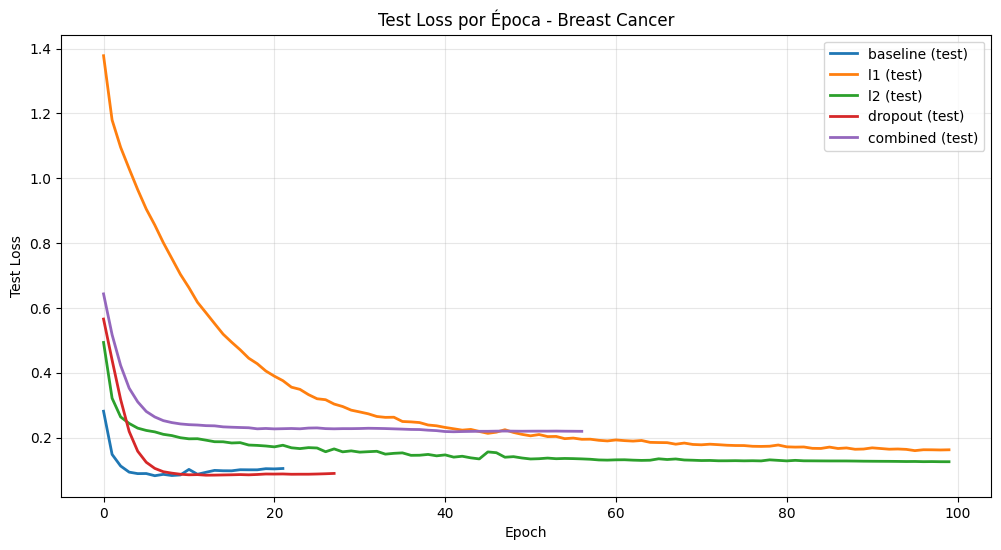

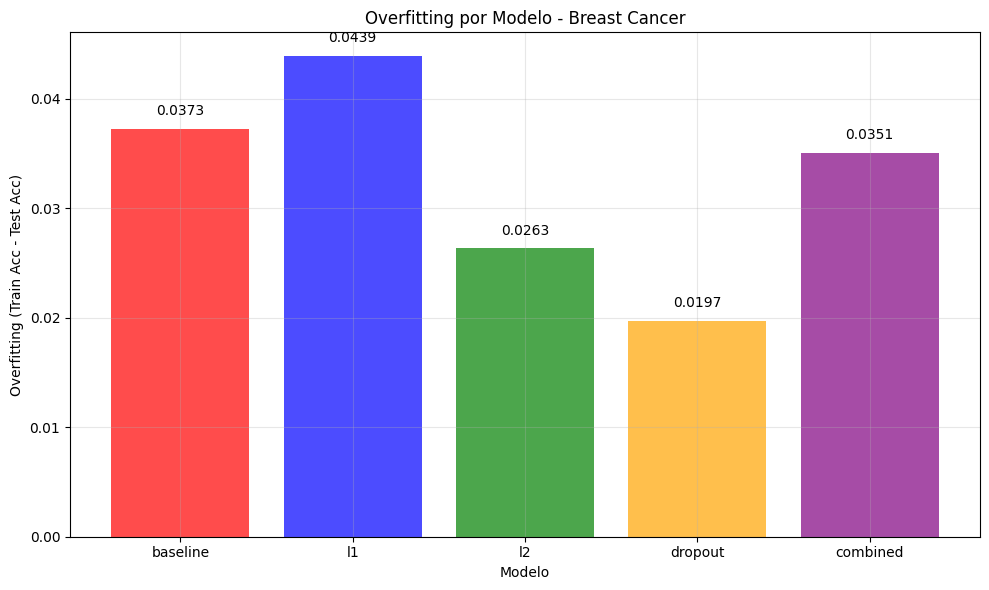

In [7]:
# Plot 1: Loss por época para cada modelo
plt.figure(figsize=(12, 6))
for model_type in model_types:
    history = results[model_type]['history']
    plt.plot(history.history['val_loss'], label=f'{model_type} (test)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Test Loss por Época - Breast Cancer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Overfitting por modelo
plt.figure(figsize=(10, 6))
overfitting_values = [results[model]['train_accuracy'] - results[model]['test_accuracy'] for model in model_types]
bars = plt.bar(model_types, overfitting_values, alpha=0.7, color=['red', 'blue', 'green', 'orange', 'purple'])
plt.xlabel('Modelo')
plt.ylabel('Overfitting (Train Acc - Test Acc)')
plt.title('Overfitting por Modelo - Breast Cancer')
plt.grid(True, alpha=0.3)

# Adicionar valores nas barras
for i, (bar, value) in enumerate(zip(bars, overfitting_values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


para o modelo de tamanho medio, o modelo com dropout e a combinação de dropout e regularização l2 apresentaram os melhores resultados.